# ECE1508: Deep Generative Models -- SUM25
## Assignment 2: Explicit Methods for Data Generation
### Programming Part
This assignment reviews explicit generation methods, as well as some basic experiment with image generation. For each task, some explanations have been given and some starter code has been provided. Please complete the provided code and report your observations and conclusions for each part in the provided markdown. For submission, please pay attention to the instructions. Failure to following the instructions can lead to mark deduction.

Let's start with loading necessary libraries. And defining the `device`.

In [1]:
import torch, torchvision
from torch.utils.data import DataLoader, Subset, random_split
import torch.nn as nn
import torch.nn.functional as F

import torchvision.transforms as transforms
from torchvision.datasets import CIFAR10, MNIST
import matplotlib.pyplot as plt


import numpy as np
import random
import math

# select a device that we want to shift the process on: cuda, cpu, mps
if torch.backends.mps.is_built():
    device = "mps"
elif torch.backends.cuda.is_built():
    device = "cuda"
else:
    device = "cpu"

## Programming Question 1: Image Inpainiting with Masked CNN

### General Overview
In this assignment, we intend to train a masked CNN model for _image inpainting._ Image inpainting refers to completing or fixing missed or corrupted pixels in an image. This is one of the well-known tasks, we can do by generative model, especially the AR models, as then can predict each pixel given its neighboring ones. In the sequel, we do this step by step.

### Dataset Loading
As the first step we load `CIFAR-10`.

In [2]:
# Define transformation: resize, tensorize, normalize
transform = transforms.Compose([
   transforms.Resize(24),  # Optional: downsample if you have limited computation
    # COMPLETE
   transforms.ToTensor(),
])

# Load CIFAR-10
full_dataset = CIFAR10(root='./data', train=True, download=True, transform=transform)

# Select only three classes for simplicity and fast training
target_classes = ['airplane', 'cat', 'dog']
class_to_idx = {name: i for i, name in enumerate(full_dataset.classes)}
selected_indices = [i for i, (_, label) in enumerate(full_dataset) if full_dataset.classes[label] in target_classes]

# shuffle and subsample to k images
random.seed(42) # for reproducibility
# COMPLETE  # k images are selected at random
from math import floor
sample_indices = random.sample(selected_indices, floor(len(selected_indices)/10))

# sample the subset
# COMPLETE
subset = Subset(full_dataset, sample_indices)

# Split into train/test
train_ratio = 0.8
train_size = int(train_ratio * len(subset)) # COMPLETE
test_size = len(subset) - train_size # COMPLETE
train_subset, test_subset = random_split(
    subset,
    [train_size, test_size],
    generator=torch.Generator().manual_seed(42)   # reproducible split
) # COMPLETE

# Create loaders
batch_size = 32
train_loader = DataLoader(train_subset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_subset, batch_size=batch_size, shuffle=False)

100%|██████████| 170M/170M [00:03<00:00, 43.6MB/s]


### Looking into some example
Let's write a function to show the first `N` images of a batch of images.

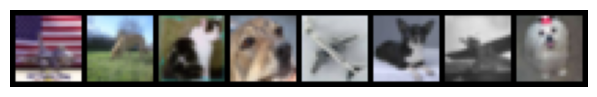

In [3]:
# Show a few images from loader
def show_samples(image_batch, N=8):
    '''
    N: number of samples
    '''
    grid = torchvision.utils.make_grid(image_batch[:N], nrow=N)
    npimg = grid.numpy()
    plt.figure(figsize=(N,1))
    plt.imshow(np.transpose(npimg, (1, 2, 0)))
    plt.axis('off')
    plt.show()

# Preview a batch
batch = next(iter(test_loader))
image_batch, _ = batch
# COMPLETE
show_samples(image_batch)

### Masking for Image Corruption
We now write a function that can _mask_ some pixels in images. We consider both `block` and `random` masking.

In [9]:
def apply_mask(images, mask_type='block', mask_ratio=0.5):
    """
    Apply a mask to a batch of images.
    Args:
        images: Tensor of shape [B, C, H, W] == batch, channel_num, height, width
        mask_type: 'block' or 'random'
        mask_ratio: fraction of image pixels to mask
    Returns:
        masked_images: Tensor with masked pixels set to 0 of shape [B, C, H, W]
        masks: Binary mask (1 = visible, 0 = masked) of shape [B, C, H, W]
    """
    # read the shapes
    B, C, H, W = images.shape

    # We consider the same mask for all channels
    # start with all ones
    masks = torch.ones((B, 1, H, W), dtype=torch.float32, device=images.device) # COMPLETE

    if mask_type == 'block':
        # Mask a center block (e.g., 50% area)
        # COMPLETE
        block_pixels = int(mask_ratio * H * W)
        side = int((block_pixels) ** 0.5)
        top = (H - side) // 2
        left = (W - side) // 2
        masks[:, :, top : top + side, left : left + side] = 0.0

    elif mask_type == 'random':
        # Mask pixels randomly
        for i in range(B):
            # COMPLETE
            num_pixels = int(mask_ratio * H * W)
            indices = torch.randperm(H * W, device=images.device)[:num_pixels]
            masks[i, 0].view(-1)[indices] = 0.0

    # Copy the mask in all C channels
    masks = masks.expand(-1, C, -1, -1)

    # Apply mask to the images
    masked_images = images * masks

    return masked_images, masks


Now let's take a look at a few masked images using the `show_samples()` function.

In [8]:
print(device)

cuda


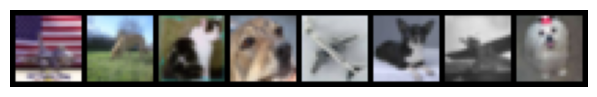

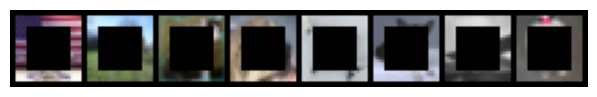

In [10]:
# Get a batch of images
images, _ = next(iter(test_loader))

# Apply mask
masked_images, masks = apply_mask(
    images=images,
    mask_type='block',
    mask_ratio=0.5
) # COMPLETE

# Preview original and masked ones
# COMPLETE
show_samples(images)
show_samples(masked_images)




### Implementing AR Model
We next implement a masked CNN to learn the data distribution in AR manner. To this end, we first modify the class `nn.Conv2d` to `MaskedConv2d` which further applies masking.

In [11]:
class MaskedConv2d(nn.Conv2d):
    def __init__(self, *args, mask_type = 'B', **kwargs):
        super().__init__(*args, **kwargs)
        assert mask_type in ['A', 'B']
        self.register_buffer('mask', torch.ones_like(self.weight.data))
        _, _, h, w = self.weight.size()
        # add mask to the convolution
        # COMPLETE
        mask = torch.ones_like(self.weight)
        yc, xc = h // 2, w // 2           # centre of the kernel

        mask[:, :, yc + 1 :, :]  = 0.     # rows *below* centre
        mask[:, :, yc,  xc + 1:] = 0.     # same row, pixels to the *right*

        if mask_type == 'A':              # first layer: also zero centre pixel
            mask[:, :, yc, xc] = 0.

        self.register_buffer("mask", mask)

    def forward(self, x):
        # COMPLETE
        return F.conv2d(
            x, self.weight * self.mask, self.bias,
            self.stride, self.padding, self.dilation, self.groups)


Using `MaskedConv2d`, we now implement a simple Masked CNN with 3 masked convolutional layers with the first two layers being ReLU-activated. For the first layer use `mask_type = 'A'` and for the remaining `mask_type = 'B'`.

In [12]:
class MyMaskedCNN(nn.Module):
    def __init__(self, in_channels=3, hidden_channels=64, num_classes=256):
        super().__init__()
        self.num_channels = in_channels
        self.num_classes = num_classes

        self.net = nn.Sequential(
            # COMPLETE
            # No softmax here — let CrossEntropyLoss handle logits
            MaskedConv2d(in_channels, hidden_channels,
                         kernel_size=3, padding=1, mask_type='A'),
            nn.ReLU(),

            MaskedConv2d(hidden_channels, hidden_channels,
                         kernel_size=3, padding=1, mask_type='B'),
            nn.ReLU(),

            MaskedConv2d(hidden_channels,
                         out_channels=self.num_classes * in_channels,
                         kernel_size=3, padding=1, mask_type='B'),
        )

    def forward(self, x):
       # COMPLETE
       logits = self.net(x)
       return logits


### Training Masked CNN
We next train the masked CNN using teacher-forcing technique: in each iteration, we pass masked image (corrupted one) through the model and compare it against the true image.

In [13]:
def train_model(model, dataloader, num_epochs=30, lr=1e-3, mask_type='block', num_classes=256):
    model = model.to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    loss_fn = nn.CrossEntropyLoss(reduction='none')  # mask-aware

    for epoch in range(num_epochs):
        total_loss = 0.0
        for images, _ in dataloader:
            images = images.to(device)  # [B, 3, H, W]
            masked_images, masks = apply_mask(
                images, mask_type=mask_type,
            )# COMPLETE
            masked_images = masked_images.to(device)
            masks = masks.to(device)

            # Quantize target pixel values from (0,1) back to integer class labels (0–255)
            labels = (images * 255).long()  # COMPLETE  # [B, 3, H, W]

            B, C, H, W = masked_images.shape
            output = model(masked_images).view(B, 3, 256, H, W)# COMPLETE # [B, 3, 256, H, W]

            loss = 0.0
            for ch in range(3):
                # Get channel-specific logits and targets
                logits = output[:, ch]# COMPLETE     # [B, 256, H, W]
                target_ch = labels [:, ch]# COMPLETE   # [B, H, W]
                mask_ch = 1.0 - masks [:, ch]# COMPLETE  # [B, H, W], 1: hidden

                ce = loss_fn(logits, target_ch) * mask_ch

                loss +=  ce.sum() / ((mask_ch.sum()) + 1e-8) # avoid 0 denominator
                # COMPLETE

            loss = loss / 3.0  # average over 3 channels

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            total_loss += loss.item()

        print(f"Epoch {epoch+1}/{num_epochs}, Loss: {total_loss / len(dataloader):.4f}")



We can now train the masked CNN.

In [14]:
model = MyMaskedCNN()  # COMPLETE
train_model(model, train_loader)
# COMPLETE by `train_model` function

Epoch 1/30, Loss: 5.4839
Epoch 2/30, Loss: 5.4289
Epoch 3/30, Loss: 5.4026
Epoch 4/30, Loss: 5.3840
Epoch 5/30, Loss: 5.3676
Epoch 6/30, Loss: 5.3510
Epoch 7/30, Loss: 5.3373
Epoch 8/30, Loss: 5.3255
Epoch 9/30, Loss: 5.3151
Epoch 10/30, Loss: 5.3106
Epoch 11/30, Loss: 5.3035
Epoch 12/30, Loss: 5.2896
Epoch 13/30, Loss: 5.2824
Epoch 14/30, Loss: 5.2794
Epoch 15/30, Loss: 5.2742
Epoch 16/30, Loss: 5.2681
Epoch 17/30, Loss: 5.2644
Epoch 18/30, Loss: 5.2601
Epoch 19/30, Loss: 5.2533
Epoch 20/30, Loss: 5.2542
Epoch 21/30, Loss: 5.2511
Epoch 22/30, Loss: 5.2451
Epoch 23/30, Loss: 5.2425
Epoch 24/30, Loss: 5.2440
Epoch 25/30, Loss: 5.2433
Epoch 26/30, Loss: 5.2370
Epoch 27/30, Loss: 5.2358
Epoch 28/30, Loss: 5.2332
Epoch 29/30, Loss: 5.2321
Epoch 30/30, Loss: 5.2280


### Sampling and Inpainting
We now sample from the model: we pass the masked images (from test set) and autoregressively sample from it.

In [15]:
def autoregressive_sample(model, masked_images, mask, num_classes=256, visualize=True):
    model.eval()

    B, C, H, W = masked_images.shape
    masked_images = masked_images.to(device)
    mask = mask.to(device)

    sampled = masked_images.clone()

    with torch.no_grad():
        for i in range(H):
            for j in range(W):
                for ch in range(C):  # RGB channels
                    # Only predict if pixel was masked
                    to_fill = (mask[:, ch, i, j] == 0)
                    if to_fill.sum() == 0:
                        continue

                    out = model(sampled).view(B, 3, 256, H, W) # COMPLETE
                    logits = out[:, ch, :, i, j] # COMPLETE # [B, 256] logits for pixel (i,j)

                    probs = F.softmax(logits, dim=1) # COMPLETE
                    sampled_values = torch.multinomial(probs, 1).squeeze(1) # COMPLETE #sample using torch.multinomial

                    # Scale back to [0, 1]
                    sampled_values =  sampled_values.float() / 255.0 # COMPLETE

                    sampled[to_fill, ch, i, j] = sampled_values

    if visualize:
        for i in range(min(B, 8)):
            fig, axs = plt.subplots(1, 3, figsize=(9, 3))
            axs[0].imshow(np.transpose(image_batch[i].cpu().numpy(), (1, 2, 0)))
            axs[1].imshow(np.transpose(masked_images[i].cpu().numpy(), (1, 2, 0)))
            axs[2].imshow(np.transpose(sampled[i].cpu().numpy(), (1, 2, 0)))
            for ax in axs: ax.axis('off')
            axs[0].set_title("Original")
            axs[1].set_title("Masked")
            axs[2].set_title("Sampled")
            plt.show()

    return sampled

Let us now have a few samples.

In [ ]:
image_batch, _ = next(iter(test_loader))
masked_images, mask = # COMPLETE

# COMPLETE using `autoregressive_sample`

### Characterizing MSE and PSNR
Two evaluation metrics we can use to evaluate inpainting are MSE and PSNR. In MSE, we compute the difference between the true and reconstructed images. PSNR is defined as

$$ \mathrm{PSNR} = \frac{x_{\max}^2}{\mathrm{MSE}} $$

for some maximum value $x_{\max}$. PSNR is typically reported in dB. We now implement these two metrics.

In [ ]:
# Compute the MSE
def compute_mse(original, reconstructed, mask):
    """
    Computes MSE only over masked regions.
    """
    # COMPLETE
    return mse.item()

# Compute PSNR
def compute_psnr(original, reconstructed, mask, max_val=1.0):
    """
    Computes PSNR over masked regions.
    """
    # COMPLETE
    return psnr

We next implement a function that sketches the performance of the trained model against the `mask_ratio`, i.e., the fraction of pixels missing.

In [ ]:
def evaluate_model_vs_mask_ratio(model, dataloader, ratios=[0.1, 0.2, 0.4, 0.6, 0.8]):
    model.eval()
    psnrs = []
    mses = []

    with torch.no_grad():
        for ratio in ratios:
            total_psnr = 0.0
            total_mse = 0.0
            num_batches = 0

            for images, _ in dataloader:
                images = images.to(device)

                # Mask images with the given ratios
                masked_images, masks = # COMPLETE

                # reconstruct by AR sampling
                reconstructed = # COMPLETE

                # compute MSE
                batch_mse = # COMPLETE
                total_mse += batch_mse

                # compute PSNR
                batch_psnr = # COMPLETE
                total_psnr += batch_psnr

                # update batch counter
                num_batches += 1

                # Optional: limit for speed
                if num_batches == 10:
                    break

            # COMPLETE # update <mses>
            # COMPLETE # update <psnrs>

    return ratios, mses, psnrs


Let us call `evaluate_model_vs_mask_ratio` and plot it.

In [ ]:
ratios, mses, psnrs = # COMPLETE

# Plot MSE vs ratio
plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.plot(ratios, mses, marker='o')
plt.xlabel('Mask Ratio')
plt.ylabel('MSE')
plt.title('MSE vs Mask Ratio')
plt.grid(True)

# Plot PSNR vs mask ratio
plt.subplot(1, 2, 2)
plt.plot(ratios, psnrs, marker='o', color='green')
plt.xlabel('Mask Ratio')
plt.ylabel('PSNR (dB)')
plt.title('PSNR vs Mask Ratio')
plt.grid(True)

# show plots
plt.tight_layout()
plt.show()


### What do you conclude from the above figures?

_Complete_

## Programming Question 2: MNIST Generation with Real NVP
### General Overview
In this question, we implement a basic real NVP model for MNIST image generation. In our implementation, we use the alternative form of flow models we saw in Written Question 2.

### Data
Let us first load MNIST. We flatten MNIST, as we want $x$ to be a vector.

In [ ]:
# Transform to [0,1] and flatten
transform = transforms.Compose([
    # COMPLETE
])

# Load flattened MNIST
train_dataset = MNIST(root='./data', train=True, download=True, transform=transform)
test_dataset = MNIST(root='./data', train=False, download=True, transform=transform)

# construct data loaders
train_loader = # COMPLETE
test_loader = # COMPLETE

### Implementing Real NVP
We now implement realNVP unit. In this implementation, we assume $z = f_{\bold{w}} (x)$. Nevertheless, the other form is also accepted and will end to the same result. For _scaling_ and _translation_ models we use the following simple MLPs:

* Scaling: 2 Layer MLP with first later being ReLU-activated and the second layer being Tanh-activated
* Translation: 2 Layer MLP with first later being ReLU-activated and the second layer not activated

We implement both `forward` and `inverse` methods to map $x$ to $z$ and reverse.

In [ ]:
class realNVP_Unit(nn.Module):
    def __init__(self, input_dim, hidden_dim, mask):
        super().__init__()
        # binary mask: 0s and 1s
        # this mask performs the split (used for coupling),
        # i.e., for x_{<r} mask == 1
        # for x_{>=r} mask == 0
        self.mask = mask

        # Scaling network (MLP)
        self.scale_net = nn.Sequential(
            # COMPLETE
        )

        # Translation network (MLP)
        self.translate_net = nn.Sequential(
            # COMPLETE
        )

    def forward(self, x):
        # COMPLETE

        return z, log_det_jacobian

    def inverse(self, z):
        # COMPLETE
        return x

We can now use the `realNVP_Unit` to implement a deep RealNVP model.

In [ ]:
class RealNVP(nn.Module):
    def __init__(self, input_dim, hidden_dim, num_units):
        super().__init__()
        self.layers = nn.ModuleList()
        self.masks = [self._create_mask(i, input_dim) for i in range(num_units)]

        # COMPLETE make multiple layers of realNVP unit

        # Set Latent to be Normal
        self.base_dist = # COMPLETE


    def _create_mask(self, layer_idx, dim):
        # COMPLETE # make a split for masking of your choice
        # A suggestion: alternating 0's and 1's
        return mask

    # go gradually from x to z
    def forward(self, x):
        # COMPLETE
        return x, log_det

    # go gradually from z to x
    def inverse(self, z):
        # COMPLETE
        return z

    # compute log likelihood
    def log_likelihood(self, x):
        # COMPLETE


    # sample from the model
    def sample(self, num_samples):
        # COMPLETE

Let's instantiate the model and take a sample from it to see how it looks like.

In [ ]:
# fit the model to MNIST data
input_dim = 28 * 28
hidden_dim = 512
num_units = 6
model = # COMPLETE

We now write a function to sample and plot our sample.

In [ ]:
def sample_and_plot(model, num_samples=16):
    # COMPLETE # sample the model

    grid = torch.cat([samples[i] for i in range(num_samples)], dim=2)
    plt.imshow(grid.squeeze(), cmap="gray")
    plt.axis("off")
    plt.title("Generated Samples")
    plt.show()


and use it to sample our model

In [ ]:
sample_and_plot(model, num_samples=1)

### Explain what you see.
_Complete_

### Training Loop
Let us now complete a training loop for the RealNVP Model.

In [ ]:
def train(model, train_loader, num_epochs=20):
    model.train()
    optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

    for epoch in range(num_epochs):
        total_loss = 0
        for x, _ in train_loader:
            x = x.to(device)

            # Compute loss and optimize
            # COMPLETE


        avg_loss = total_loss / len(train_loader)
        print(f"Epoch [{epoch+1}/{num_epochs}], Loss: {avg_loss:.4f}")


We now train our model.

In [ ]:
# COMPLETE use `train`

Let's sample the model once again.

In [ ]:
sample_and_plot(model, num_samples=1)

### Explain your observation.
_Complete_

### Propose a metric to evaluate the quality of the generated image, which can explain the higher quality of the trained model as compared to untrained one.
_Complete_